**Name:** Abdul Hanan  
**Matriculation No:** 9285859

### Scoria Cone Classification using SVM

#### Goal

The goal of this project is to classify small patches of raster as:

```text
1 = cone
0 = not cone
```

This follows a classical image classification pipeline:

```text
image patch → numerical image representation → SVM classifier → cone / not cone
```

Positive examples are extracted around known Etna cone-base centroids. Negative examples are random terrain patches far from known cone centroids.

#### Why this method?

The data contains polygons. From each polygon, I calculated a centroid and croped a small image patch around it. This creates a positive example (Cone).

For negative examples, I randomly choose locations that are far away from known cone centroids and crop patches there.

Then every patch is converted into numerical features. These features describe brightness, contrast, roughness, edges, and blob-like shape. Finally, an SVM learns to separate cone patches from non-cone patches.



In [1]:
# Import libraries

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
import rasterio
from rasterio.windows import Window
from rasterio.transform import rowcol, xy
from rasterio.enums import Resampling

from affine import Affine
from scipy.spatial import cKDTree
from scipy.ndimage import generic_filter

from skimage.feature import blob_log
from skimage.exposure import rescale_intensity
from skimage.filters import gaussian

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

plt.rcParams["figure.figsize"] = (8, 6)
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

#### File paths

I used the Etna NW hillshade raster because hillshade makes terrain shapes easier to see than the raw DEM.

In [2]:

BASE_DIR = r"C:\Users\Abdul Hanan\Downloads\CinderConesDataPack"

ETNA_BASES_SHP = os.path.join(BASE_DIR, "Etna", "Coni", "coni_monogenici.shp")
ETNA_CRATERS_SHP = os.path.join(BASE_DIR, "Etna", "Coni", "crateri.shp")

ETNA_NW = os.path.join(BASE_DIR, "Etna", "Etna-Eduard-Analytical-NW.tiff")
ETNA_NE = os.path.join(BASE_DIR, "Etna", "Etna-Eduard-Analytical-NE.tiff")
ETNA_TEXTURE = os.path.join(BASE_DIR, "Etna", "Etna-Eduard-Texture.tiff")

print("Cone-base shapefile exists:", os.path.exists(ETNA_BASES_SHP))
print("NW hillshade raster exists:", os.path.exists(ETNA_NW))

Cone-base shapefile exists: True
NW hillshade raster exists: True


#### Load cone-base shapefile

The Etna cone-base file stores cone bases as polygons and multipolygons. These are useful because each polygon represents one mapped cone base.

In [3]:
etna_bases = gpd.read_file(ETNA_BASES_SHP)

print("Number of Etna cone-base features:", len(etna_bases))
print("\nGeometry types:")
print(etna_bases.geom_type.value_counts())

print("\nColumns:")
print(etna_bases.columns)

etna_bases.head()

Number of Etna cone-base features: 230

Geometry types:
Polygon         209
MultiPolygon     21
Name: count, dtype: int64

Columns:
Index(['Id', 'age', 'age_range', 'slope_rang', 'geometry'], dtype='object')


,Id,age,age_range,slope_rang,geometry
0,2,0,7,1.0,"POLYGON ((493656.661 4180020.234, 493667.606 4..."
1,12,0,2,1.0,"POLYGON ((495591.298 4180747.08, 495588.138 41..."
2,13,0,2,3.0,"POLYGON ((495959.864 4180356.29, 495959.495 41..."
3,3,1763,0,1.0,"POLYGON ((493079.841 4178054.698, 493071.021 4..."
4,7,1763,0,1.0,"MULTIPOLYGON (((494177.276 4177923.412, 494176..."


#### Read raster metadata only

The raster is large. I first read only the metadata, not the full image.

This gives the raster size, coordinate system and pixel size.

In [4]:
with rasterio.open(ETNA_NW) as src:
    raster_crs = src.crs
    raster_width = src.width
    raster_height = src.height
    raster_transform = src.transform
    pixel_size = abs(src.transform.a)

print("Raster width:", raster_width)
print("Raster height:", raster_height)
print("Raster CRS:", raster_crs)
print("Transform:", raster_transform)
print("Pixel size in meters:", pixel_size)
print("Etna bases CRS:", etna_bases.crs)

Raster width: 25717
Raster height: 27756
Raster CRS: EPSG:32633
Transform: | 2.00, 0.00, 477838.00|
| 0.00,-2.00, 4200176.00|
| 0.00, 0.00, 1.00|
Pixel size in meters: 2.0
Etna bases CRS: None


#### Handle CRS (Coordinate refernce system)

The shapefile has no CRS, so I set it to match the raster.

This is necessary because vector coordinates and raster coordinates must match.

In [5]:
if etna_bases.crs is None:
    etna_bases = etna_bases.set_crs(raster_crs, allow_override=True)
else:
    etna_bases = etna_bases.to_crs(raster_crs)

print("Etna bases CRS after:", etna_bases.crs)

Etna bases CRS after: PROJCS["WGS 84 / UTM zone 33N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32633"]]


#### Convert polygons to centroid points

For every cone-base polygon, I calculate the centroid.

```text
cone-base polygon → centroid point → center of positive patch
```

In [6]:
etna_bases["centroid"] = etna_bases.geometry.centroid
etna_bases["cx"] = etna_bases["centroid"].x
etna_bases["cy"] = etna_bases["centroid"].y

etna_centroids = etna_bases[["Id", "cx", "cy", "centroid"]].copy()

print("Number of cone centroids:", len(etna_centroids))
etna_centroids.head()

Number of cone centroids: 230


,Id,cx,cy,centroid
0,2,493656.661149,4.179867e+06,POINT (493656.661 4179866.809)
1,12,495684.669782,4.180608e+06,POINT (495684.67 4180608.298)
2,13,496075.173302,4.180236e+06,POINT (496075.173 4180235.566)
3,3,493183.326943,4.177897e+06,POINT (493183.327 4177897.118)
4,7,494239.334226,4.177945e+06,POINT (494239.334 4177945.059)


#### Low-resolution overview

This image is only used to visually check that cone centroids are aligned with the raster. The full raster is too large to display directly, so I read a smaller overview.

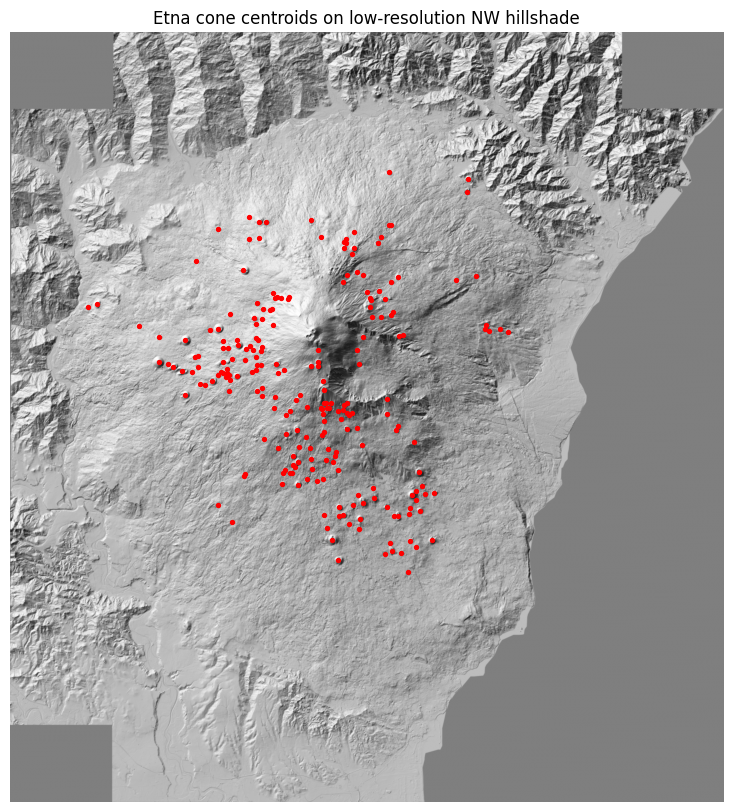

In [7]:
def read_overview(raster_path, scale=20):
    with rasterio.open(raster_path) as src:
        out_height = src.height // scale
        out_width = src.width // scale

        data = src.read(
            1,
            out_shape=(out_height, out_width),
            resampling=Resampling.bilinear
        )

        transform = src.transform * Affine.scale(
            src.width / out_width,
            src.height / out_height
        )

    return data, transform

overview, overview_transform = read_overview(ETNA_NW, scale=20)

overview_rows = []
overview_cols = []

for x_coord, y_coord in zip(etna_centroids["cx"], etna_centroids["cy"]):
    row, col = rowcol(overview_transform, x_coord, y_coord)
    overview_rows.append(row)
    overview_cols.append(col)

plt.figure(figsize=(10, 10))
plt.imshow(overview, cmap="gray")
plt.scatter(overview_cols, overview_rows, s=8, c="red")
plt.title("Etna cone centroids on low-resolution NW hillshade")
plt.axis("off")
plt.show()

#### Read an image patch around a coordinate

This function reads only a small window from the raster. This avoids loading the full Etna raster into memory.

In [8]:
PATCH_SIZE = 256

def read_patch_around_point(raster_path, x_coord, y_coord, patch_size=256):
    with rasterio.open(raster_path) as src:
        row, col = rowcol(src.transform, x_coord, y_coord)
        half = patch_size // 2

        window = Window(
            col_off=col - half,
            row_off=row - half,
            width=patch_size,
            height=patch_size
        )

        patch = src.read(1, window=window, boundless=True, fill_value=0)
        patch_transform = src.window_transform(window)

    return patch, patch_transform

#### Show positive examples

Positive examples are patches centered on known cone centroids.

```text
label = 1
```

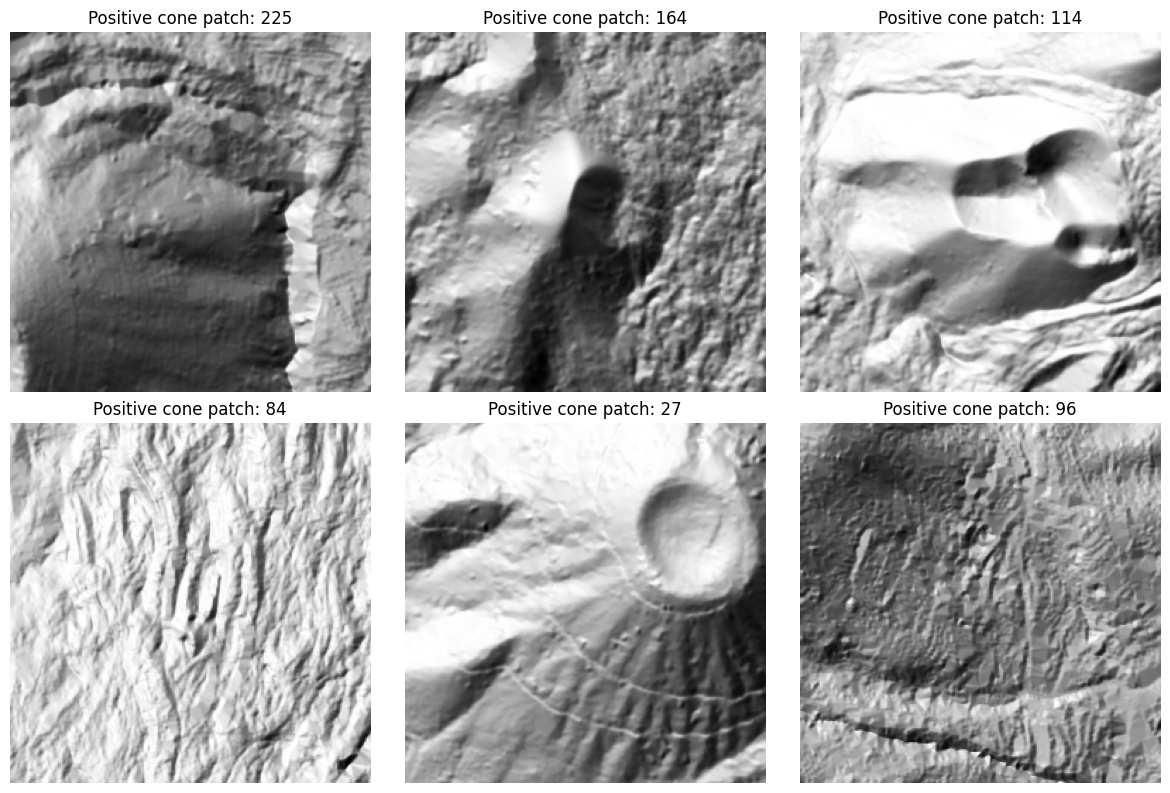

In [9]:
sample_positive = etna_centroids.sample(6, random_state=RANDOM_STATE)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_positive.iterrows(), start=1):
    patch, _ = read_patch_around_point(
        ETNA_NW,
        row["cx"],
        row["cy"],
        patch_size=PATCH_SIZE
    )

    plt.subplot(2, 3, i)
    plt.imshow(patch, cmap="gray")
    plt.title(f"Positive cone patch: {row['Id']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Sample negative locations

Negative examples are random points at least 400 meters away from known cone centroids. This reduces the chance of accidentally sampling a known cone.

In [10]:
cone_points = etna_centroids[["cx", "cy"]].values
cone_tree = cKDTree(cone_points)

def sample_negative_points(
    raster_path,
    n_points,
    min_distance_from_cone=400,
    patch_size=256,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    negative_points = []

    with rasterio.open(raster_path) as src:
        half = patch_size // 2
        attempts = 0
        max_attempts = n_points * 500

        while len(negative_points) < n_points and attempts < max_attempts:
            attempts += 1

            row = rng.integers(half, src.height - half)
            col = rng.integers(half, src.width - half)

            x_coord, y_coord = xy(src.transform, row, col)
            nearest_distance, _ = cone_tree.query([x_coord, y_coord])

            if nearest_distance >= min_distance_from_cone:
                negative_points.append({
                    "x": x_coord,
                    "y": y_coord,
                    "nearest_cone_distance": nearest_distance
                })

    return pd.DataFrame(negative_points)

negative_points = sample_negative_points(
    ETNA_NW,
    n_points=len(etna_centroids),
    min_distance_from_cone=400,
    patch_size=PATCH_SIZE,
    random_state=RANDOM_STATE
)

print("Negative points sampled:", len(negative_points))
negative_points.head()

Negative points sampled: 230


,x,y,nearest_cone_distance
0,517505.0,4195011.0,8575.343858
1,500443.0,4163919.0,546.076561
2,521815.0,4176105.0,8436.185012
3,513605.0,4195193.0,6245.307511
4,482889.0,4188839.0,8377.906710


#### Show negative examples

Negative examples are patches far from known cone centers.

```text
label = 0
```

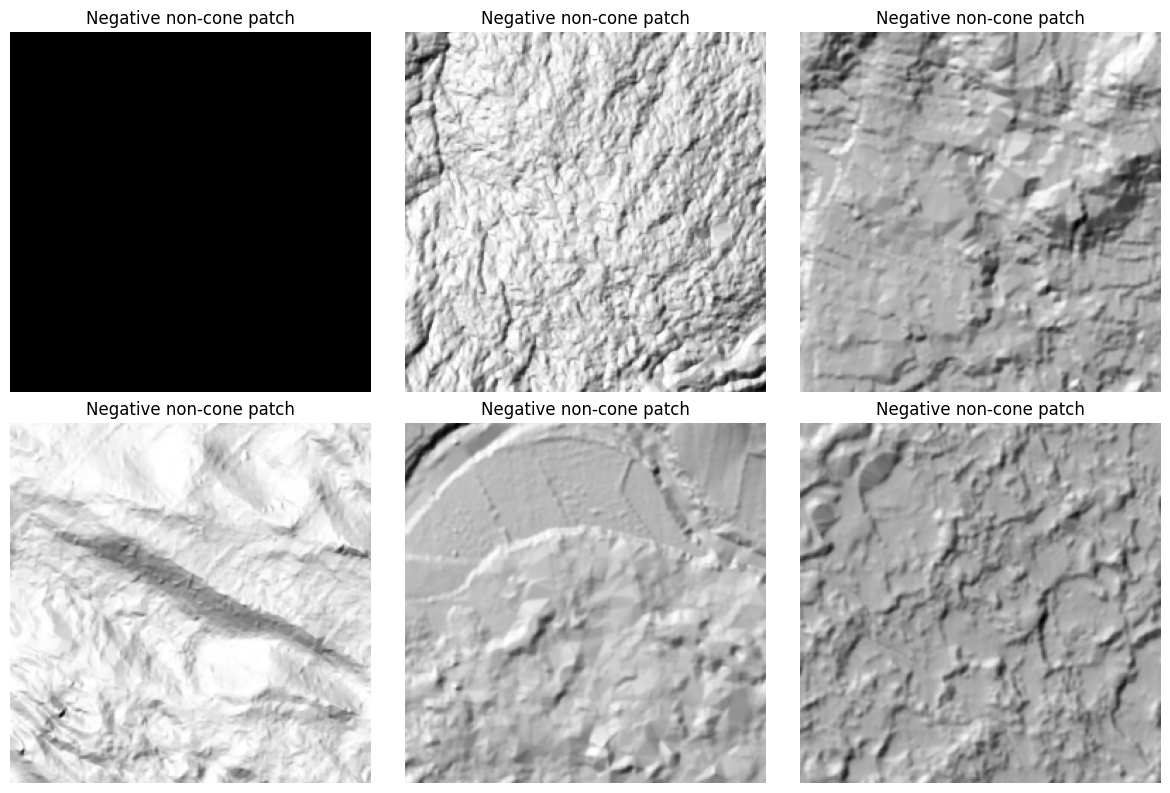

In [11]:
sample_negative = negative_points.sample(6, random_state=RANDOM_STATE)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_negative.iterrows(), start=1):
    patch, _ = read_patch_around_point(
        ETNA_NW,
        row["x"],
        row["y"],
        patch_size=PATCH_SIZE
    )

    plt.subplot(2, 3, i)
    plt.imshow(patch, cmap="gray")
    plt.title("Negative non-cone patch")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Feature extraction

SVM needs numerical input. I therefore convert each image patch into a feature vector.

The features include:

- brightness statistics
- center vs ring statistics
- edge strength
- roughness
- blob count and blob radius

In [12]:
def normalize_patch(patch):
    patch = patch.astype("float32")
    patch = np.nan_to_num(patch, nan=np.nanmedian(patch))

    if np.nanmax(patch) == np.nanmin(patch):
        return np.zeros_like(patch, dtype="float32")

    return rescale_intensity(patch, out_range=(0, 1)).astype("float32")

def extract_patch_features(patch):
    img = normalize_patch(patch)

    h, w = img.shape
    cy, cx = h // 2, w // 2
    center_half = h // 4

    center = img[
        cy - center_half: cy + center_half,
        cx - center_half: cx + center_half
    ]

    ring_mask = np.ones_like(img, dtype=bool)
    ring_mask[
        cy - center_half: cy + center_half,
        cx - center_half: cx + center_half
    ] = False
    ring = img[ring_mask]

    gy, gx = np.gradient(img)
    edge = np.sqrt(gx ** 2 + gy ** 2)

    roughness = generic_filter(img, np.std, size=5)

    smooth = gaussian(img, sigma=1)
    blobs = blob_log(
        smooth,
        min_sigma=5,
        max_sigma=30,
        num_sigma=8,
        threshold=0.08
    )

    if len(blobs) > 0:
        blob_radii = blobs[:, 2] * np.sqrt(2)
        blob_count = len(blobs)
        largest_blob_radius = float(np.max(blob_radii))
        mean_blob_radius = float(np.mean(blob_radii))
    else:
        blob_count = 0
        largest_blob_radius = 0.0
        mean_blob_radius = 0.0

    return {
        "mean": float(np.mean(img)),
        "std": float(np.std(img)),
        "min": float(np.min(img)),
        "max": float(np.max(img)),
        "q25": float(np.quantile(img, 0.25)),
        "q50": float(np.quantile(img, 0.50)),
        "q75": float(np.quantile(img, 0.75)),
        "center_mean": float(np.mean(center)),
        "center_std": float(np.std(center)),
        "ring_mean": float(np.mean(ring)),
        "ring_std": float(np.std(ring)),
        "center_minus_ring": float(np.mean(center) - np.mean(ring)),
        "edge_mean": float(np.mean(edge)),
        "edge_std": float(np.std(edge)),
        "roughness_mean": float(np.mean(roughness)),
        "roughness_std": float(np.std(roughness)),
        "blob_count": float(blob_count),
        "largest_blob_radius": largest_blob_radius,
        "mean_blob_radius": mean_blob_radius
    }

#### Build positive feature table

Each row is a known cone patch.

In [13]:
positive_rows = []

for _, row in etna_centroids.iterrows():
    patch, _ = read_patch_around_point(
        ETNA_NW,
        row["cx"],
        row["cy"],
        patch_size=PATCH_SIZE
    )

    features = extract_patch_features(patch)
    features["label"] = 1
    features["example_type"] = "positive"
    features["x"] = row["cx"]
    features["y"] = row["cy"]
    features["Id"] = row["Id"]

    positive_rows.append(features)

positive_df = pd.DataFrame(positive_rows)

print("Positive examples:", len(positive_df))
positive_df.head()

Positive examples: 230


,mean,std,min,max,q25,q50,q75,center_mean,center_std,ring_mean,...,roughness_mean,roughness_std,blob_count,largest_blob_radius,mean_blob_radius,label,example_type,x,y,Id
0,0.791168,0.169924,0.0,1.0,0.720000,0.831111,0.915556,0.761360,0.226912,0.801104,...,0.064173,0.038250,34.0,32.324882,10.190657,1,positive,493656.661149,4.179867e+06,2
1,0.685956,0.230471,0.0,1.0,0.571429,0.744898,0.852041,0.650735,0.284406,0.697697,...,0.055279,0.045503,41.0,42.426407,14.216049,1,positive,495684.669782,4.180608e+06,12
2,0.756249,0.213421,0.0,1.0,0.651685,0.814607,0.921348,0.703667,0.279474,0.773776,...,0.050854,0.040476,52.0,42.426407,11.247660,1,positive,496075.173302,4.180236e+06,13
3,0.717938,0.245056,0.0,1.0,0.613065,0.793970,0.894472,0.587015,0.336520,0.761579,...,0.050638,0.045412,47.0,42.426407,12.659146,1,positive,493183.326943,4.177897e+06,3
4,0.788776,0.195507,0.0,1.0,0.706897,0.827586,0.942529,0.717928,0.288079,0.812392,...,0.051664,0.049879,52.0,42.426407,10.762010,1,positive,494239.334226,4.177945e+06,7


#### Build negative feature table

Each row is a random non-cone patch.

In [14]:
negative_rows = []

for idx, row in negative_points.iterrows():
    patch, _ = read_patch_around_point(
        ETNA_NW,
        row["x"],
        row["y"],
        patch_size=PATCH_SIZE
    )

    features = extract_patch_features(patch)
    features["label"] = 0
    features["example_type"] = "negative"
    features["x"] = row["x"]
    features["y"] = row["y"]
    features["Id"] = f"neg_{idx}"

    negative_rows.append(features)

negative_df = pd.DataFrame(negative_rows)

print("Negative examples:", len(negative_df))
negative_df.head()

Negative examples: 230


,mean,std,min,max,q25,q50,q75,center_mean,center_std,ring_mean,...,roughness_mean,roughness_std,blob_count,largest_blob_radius,mean_blob_radius,label,example_type,x,y,Id
0,0.503280,0.256788,0.0,1.0,0.285047,0.500000,0.724299,0.535349,0.220265,0.492590,...,0.058602,0.040966,57.0,42.426407,11.501561,0,negative,517505.0,4195011.0,neg_0
1,0.659892,0.166042,0.0,1.0,0.562814,0.678392,0.768844,0.674007,0.143878,0.655187,...,0.054074,0.040510,75.0,42.426407,9.899495,0,negative,500443.0,4163919.0,neg_1
2,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0,negative,521815.0,4176105.0,neg_2
3,0.646911,0.212912,0.0,1.0,0.509615,0.677885,0.788462,0.562253,0.227998,0.675130,...,0.059785,0.044623,64.0,32.324882,10.543467,0,negative,513605.0,4195193.0,neg_3
4,0.840367,0.110808,0.0,1.0,0.767442,0.866279,0.924419,0.843338,0.088830,0.839376,...,0.028647,0.025130,10.0,42.426407,12.121830,0,negative,482889.0,4188839.0,neg_4


#### Combine and clean the dataset

I combine positive and negative examples. Then I remove invalid patches with almost no variation, because those are likely no-data regions.

In [15]:
dataset = pd.concat([positive_df, negative_df], ignore_index=True)

print("Total examples before cleaning:", len(dataset))
print("\nClass counts before cleaning:")
print(dataset["label"].value_counts())

before = len(dataset)
dataset_clean = dataset[dataset["std"] > 0.01].copy()
after = len(dataset_clean)

print("\nExamples before cleaning:", before)
print("Examples after cleaning:", after)
print("Removed invalid examples:", before - after)

print("\nClass counts after cleaning:")
print(dataset_clean["label"].value_counts())

dataset_clean.head()

Total examples before cleaning: 460

Class counts before cleaning:
label
1    230
0    230
Name: count, dtype: int64

Examples before cleaning: 460
Examples after cleaning: 410
Removed invalid examples: 50

Class counts after cleaning:
label
1    230
0    180
Name: count, dtype: int64


,mean,std,min,max,q25,q50,q75,center_mean,center_std,ring_mean,...,roughness_mean,roughness_std,blob_count,largest_blob_radius,mean_blob_radius,label,example_type,x,y,Id
0,0.791168,0.169924,0.0,1.0,0.720000,0.831111,0.915556,0.761360,0.226912,0.801104,...,0.064173,0.038250,34.0,32.324882,10.190657,1,positive,493656.661149,4.179867e+06,2
1,0.685956,0.230471,0.0,1.0,0.571429,0.744898,0.852041,0.650735,0.284406,0.697697,...,0.055279,0.045503,41.0,42.426407,14.216049,1,positive,495684.669782,4.180608e+06,12
2,0.756249,0.213421,0.0,1.0,0.651685,0.814607,0.921348,0.703667,0.279474,0.773776,...,0.050854,0.040476,52.0,42.426407,11.247660,1,positive,496075.173302,4.180236e+06,13
3,0.717938,0.245056,0.0,1.0,0.613065,0.793970,0.894472,0.587015,0.336520,0.761579,...,0.050638,0.045412,47.0,42.426407,12.659146,1,positive,493183.326943,4.177897e+06,3
4,0.788776,0.195507,0.0,1.0,0.706897,0.827586,0.942529,0.717928,0.288079,0.812392,...,0.051664,0.049879,52.0,42.426407,10.762010,1,positive,494239.334226,4.177945e+06,7


#### Prepare feature matrix and labels

`X` is the feature table.  
`y` is the target label.

In [16]:
feature_columns = [
    "mean", "std", "min", "max", "q25", "q50", "q75",
    "center_mean", "center_std", "ring_mean", "ring_std",
    "center_minus_ring", "edge_mean", "edge_std",
    "roughness_mean", "roughness_std",
    "blob_count", "largest_blob_radius", "mean_blob_radius"
]

X = dataset_clean[feature_columns]
y = dataset_clean["label"]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (410, 19)
Label vector shape: (410,)


#### Train/test split

The test set is kept separate from training. This gives a fairer evaluation of the trained model.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

print("\nTraining class counts:")
print(y_train.value_counts())

print("\nTesting class counts:")
print(y_test.value_counts())

Training examples: 287
Testing examples: 123

Training class counts:
label
1    161
0    126
Name: count, dtype: int64

Testing class counts:
label
1    69
0    54
Name: count, dtype: int64


### Train SVM classifier

SVM needs feature scaling. I used StandardScaler() which makes features equally important so SVM doesn't favor big numbers.

The RBF kernel is used because the boundary between cone and non-cone patches may be non-linear.

In [18]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

#### Evaluate SVM

The main metrics are accuracy, precision, recall, and F1 score.

F1 is especially useful because it balances precision and recall.

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

svm_summary = pd.DataFrame([{
    "model": "SVM with RBF kernel",
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
}])

svm_summary

,model,accuracy,precision,recall,f1
0,SVM with RBF kernel,0.699187,0.735294,0.724638,0.729927


In [20]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["not cone", "cone"],
    zero_division=0
))

              precision    recall  f1-score   support

    not cone       0.65      0.67      0.66        54
        cone       0.74      0.72      0.73        69

    accuracy                           0.70       123
   macro avg       0.69      0.70      0.70       123
weighted avg       0.70      0.70      0.70       123



#### Confusion matrix

The confusion matrix shows correct and incorrect predictions for both classes.

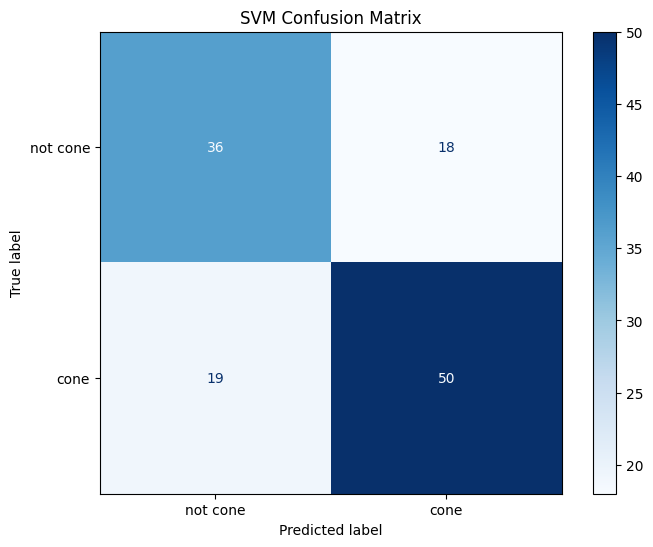

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["not cone", "cone"],
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")
plt.show()

#### Cross-validation

Because the dataset is small, I also use 5-fold cross-validation. This gives a more stable estimate of model performance.

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_f1_scores = cross_val_score(
    svm_model,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("F1 scores from 5 folds:", cv_f1_scores)
print("Mean F1:", cv_f1_scores.mean())
print("Standard deviation:", cv_f1_scores.std())

F1 scores from 5 folds: [0.86021505 0.81318681 0.8172043  0.86363636 0.84444444]
Mean F1: 0.8397373952212662
Standard deviation: 0.021096564844664857


#### Small SVM parameter tuning

This cell tries a small number of values for 'C' and 'gamma'.

It is not a huge search. It is only used to check whether a slightly better SVM setting exists.

In [23]:
param_grid = {
    "svm__C": [1, 10, 50],
    "svm__gamma": ["scale", 0.01, 0.1]
}

grid = GridSearchCV(
    svm_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation F1 on training data:", grid.best_score_)

best_svm = grid.best_estimator_

y_pred_best = best_svm.predict(X_test)
y_prob_best = best_svm.predict_proba(X_test)[:, 1]

best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best, zero_division=0)
best_recall = recall_score(y_test, y_pred_best, zero_division=0)
best_f1 = f1_score(y_test, y_pred_best, zero_division=0)

best_svm_summary = pd.DataFrame([{
    "model": "Tuned SVM",
    "accuracy": best_accuracy,
    "precision": best_precision,
    "recall": best_recall,
    "f1": best_f1
}])

best_svm_summary

Best parameters: {'svm__C': 1, 'svm__gamma': 'scale'}
Best cross-validation F1 on training data: 0.8700002703871943


,model,accuracy,precision,recall,f1
0,Tuned SVM,0.723577,0.733333,0.797101,0.763889


#### Cross-Validation for Tuned SVM

In [24]:
tuned_cv_f1_scores = cross_val_score(
    best_svm,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("Tuned SVM F1 scores from 5 folds:", tuned_cv_f1_scores)
print("Tuned SVM mean F1:", tuned_cv_f1_scores.mean())
print("Tuned SVM standard deviation:", tuned_cv_f1_scores.std())

Tuned SVM F1 scores from 5 folds: [0.86315789 0.80851064 0.84536082 0.86956522 0.85416667]
Tuned SVM mean F1: 0.8481522483669908
Tuned SVM standard deviation: 0.021443447426295136


#### Compare default and tuned SVM

The tuned SVM performed better than the first SVM model. This shows that the choice of SVM parameters has an effect on the classification result.

In this project, the task was to classify small terrain patches as either cone or not cone. The positive examples were extracted around Etna cone-base centroids, and the negative examples were sampled from random locations far from known cone centroids.

The final tuned SVM gives a reasonable result for a small dataset. This shows that the terrain features we manually calculated, such as brightness, roughness, edge strength, and blob information, are useful for separating cone patches from non-cone patches.

In [25]:
comparison = pd.concat([svm_summary, best_svm_summary], ignore_index=True)
comparison

,model,accuracy,precision,recall,f1
0,SVM with RBF kernel,0.699187,0.735294,0.724638,0.729927
1,Tuned SVM,0.723577,0.733333,0.797101,0.763889


#### Final result

This table is the main result of the project.

In [26]:
final_result = pd.DataFrame([{
    "dataset": "Etna",
    "task": "Patch classification",
    "positive_examples": int((dataset_clean["label"] == 1).sum()),
    "negative_examples": int((dataset_clean["label"] == 0).sum()),
    "classifier": "Tuned SVM",
    "feature_type": "manually calculated patch features",
    "test_accuracy": best_accuracy,
    "test_precision": best_precision,
    "test_recall": best_recall,
    "test_f1": best_f1,
    "cv_mean_f1": tuned_cv_f1_scores.mean(),
    "cv_std_f1": tuned_cv_f1_scores.std()
}])

final_result

,dataset,task,positive_examples,negative_examples,classifier,feature_type,test_accuracy,test_precision,test_recall,test_f1,cv_mean_f1,cv_std_f1
0,Etna,Patch classification,230,180,Tuned SVM,manually calculated patch features,0.723577,0.733333,0.797101,0.763889,0.848152,0.021443


The final result shows that the tuned SVM achieved a test accuracy of about 72.4%, with precision 73.3%, recall 79.7%, and F1 score 76.4%. This means the model is able to separate cone patches from non-cone patches reasonably well, especially considering that the dataset is small. The recall is higher than the precision, so the classifier finds many real cone patches, but it also still makes some false-positive mistakes. The 5-fold cross-validation mean F1 score is 84.8% with a low standard deviation of 2.1%, which suggests that the model performance is fairly stable across different train/test splits.

#### Summary

This project used a classical image classification pipeline for scoria cone recognition.

First, the Etna cone-base polygons were loaded and converted into centroid points. These centroids were used to extract positive image patches from the NW hillshade raster. Negative patches were created by sampling random terrain locations far from known cone centroids.

Each patch was then converted into a numerical feature vector. The features described brightness, contrast, center-versus-surrounding behavior, roughness, edge strength, and blob-like structures. After feature extraction, an SVM classifier was trained to classify patches as cone or not cone.

The tuned SVM gave the best result among the tested SVM models. This supports the idea that scoria cone patches can be recognized using image representations and a supervised classifier.

The main limitation is that this is patch classification, not full automatic mapping. The method can say whether a selected patch looks like a cone, but it does not directly draw cone boundaries.

## Scoria Cone Classification using CNN

The SVM model above uses **hand-crafted features** (mean, std, blob count, roughness, etc.) calculated from each patch.

A **CNN (Convolutional Neural Network)** works differently: it takes the **raw image patch directly** as input and learns its own features automatically through convolution filters, instead of relying on features I designed manually.

This section builds a CNN on the *same* positive (cone) and negative (non-cone) locations used for the SVM, so the two approaches can be compared fairly:

`image patch (raw pixels) → CNN → cone / not cone`


In [35]:
# Imports for the CNN pipeline
import numpy as np
from skimage.transform import resize

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print("TensorFlow version:", tf.__version__)

tf.random.set_seed(RANDOM_STATE)


TensorFlow version: 2.19.0


### Build the image dataset

The CNN needs the raw image patches themselves, not the hand-crafted feature table.
I reuse the same cone centroids (`etna_centroids`) and the same random negative
locations (`negative_points`) that were used for the SVM, so both models see the
same examples. Each patch is:

1. read from the raster with `read_patch_around_point` (same function as before)
2. normalized to the 0–1 range with `normalize_patch` (same function as before)
3. resized down from 256x256 to a smaller `CNN_PATCH_SIZE` so the network trains faster
4. given a channel dimension, since Conv2D layers expect shape `(height, width, channels)`


In [36]:
CNN_PATCH_SIZE = 64  # smaller than the raw 256x256 patch, keeps training fast

def build_image_and_label(x_coord, y_coord, label):
    patch, _ = read_patch_around_point(
        ETNA_NW,
        x_coord,
        y_coord,
        patch_size=PATCH_SIZE
    )
    img = normalize_patch(patch)
    img = resize(img, (CNN_PATCH_SIZE, CNN_PATCH_SIZE), anti_aliasing=True)
    img = img.astype("float32")
    return img, label

images = []
labels = []

# Positive examples (cones)
for _, row in etna_centroids.iterrows():
    img, lbl = build_image_and_label(row["cx"], row["cy"], 1)
    images.append(img)
    labels.append(lbl)

# Negative examples (non-cones)
for _, row in negative_points.iterrows():
    img, lbl = build_image_and_label(row["x"], row["y"], 0)
    images.append(img)
    labels.append(lbl)

X_img = np.stack(images)[..., np.newaxis]  # add channel dimension -> (N, H, W, 1)
y_img = np.array(labels)

print("Image dataset shape:", X_img.shape)
print("Label vector shape:", y_img.shape)
print("Class counts:", dict(zip(*np.unique(y_img, return_counts=True))))


Image dataset shape: (460, 64, 64, 1)
Label vector shape: (460,)
Class counts: {np.int64(0): np.int64(230), np.int64(1): np.int64(230)}


### Remove empty / no-data patches

Just like the SVM pipeline dropped patches with almost no variation (likely
no-data regions), I apply the same check here using each patch's standard
deviation.


In [38]:
stds = X_img.reshape(X_img.shape[0], -1).std(axis=1)
keep_mask = stds > 0.01

print("Total image examples before cleaning:", len(X_img))
X_img = X_img[keep_mask]
y_img = y_img[keep_mask]
print("Total image examples after cleaning:", len(X_img))


Total image examples before cleaning: 460
Total image examples after cleaning: 410


### Train / test split

I use the same 70/30 split ratio, the same `RANDOM_STATE`, and stratify on the
label, exactly like the SVM split, so the two models are evaluated on
comparably-sized and comparably-balanced test sets.


In [39]:
from sklearn.model_selection import train_test_split as cnn_train_test_split

X_train_img, X_test_img, y_train_img, y_test_img = cnn_train_test_split(
    X_img,
    y_img,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_img
)

# A further split of the training data gives a validation set for early stopping,
# keeping the test set completely untouched until final evaluation.
X_train_img, X_val_img, y_train_img, y_val_img = cnn_train_test_split(
    X_train_img,
    y_train_img,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_img
)

print("Training examples:", len(X_train_img))
print("Validation examples:", len(X_val_img))
print("Testing examples:", len(X_test_img))


Training examples: 229
Validation examples: 58
Testing examples: 123


### Data augmentation

The dataset is small, which makes CNNs prone to overfitting. I add light
augmentation (random flips and small rotations) as the first layers of the
model. Augmentation only ever runs during training, not during evaluation or
prediction.


In [40]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
], name="augmentation")


### Build the CNN

A small convolutional network is enough for 64x64 grayscale patches:

- three convolution + max-pooling blocks, which progressively learn edges, then
  textures, then shapes such as the cone's circular rim
- a dense layer with dropout to reduce overfitting
- a single sigmoid output neuron for the binary cone / not-cone decision


In [42]:
def build_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="scoria_cone_cnn")

cnn_model = build_cnn((CNN_PATCH_SIZE, CNN_PATCH_SIZE, 1))

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

cnn_model.summary()


Model: "scoria_cone_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ augmentation (Sequential)            │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         262,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 285,569 (1.09 MB)

 Trainable params: 285,569 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

### Train the CNN

Training stops early if validation loss stops improving, and the best weights
seen during training are restored. This helps avoid overfitting on such a
small dataset.


In [43]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train_img,
    y_train_img,
    validation_data=(X_val_img, y_val_img),
    epochs=60,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.4931 - loss: 0.6961 - precision: 0.5016 - recall: 0.7527 - val_accuracy: 0.5690 - val_loss: 0.6755 - val_precision: 0.5690 - val_recall: 1.0000
Epoch 2/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5725 - loss: 0.6758 - precision: 0.5725 - recall: 1.0000 - val_accuracy: 0.5690 - val_loss: 0.6720 - val_precision: 0.5690 - val_recall: 1.0000
Epoch 3/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5725 - loss: 0.6693 - precision: 0.5725 - recall: 1.0000 - val_accuracy: 0.5690 - val_loss: 0.6551 - val_precision: 0.5690 - val_recall: 1.0000
Epoch 4/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5725 - loss: 0.6397 - precision: 0.5725 - recall: 1.0000 - val_accuracy: 0.5690 - val_loss: 0.6257 - val_precision: 0.5690 - val_recall: 1.0000
Epoch 5/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6381 - loss: 0.6521 - precision: 0.6284 - recall: 0.9056 - val_accuracy: 0.5862 - val_loss: 0.6082 

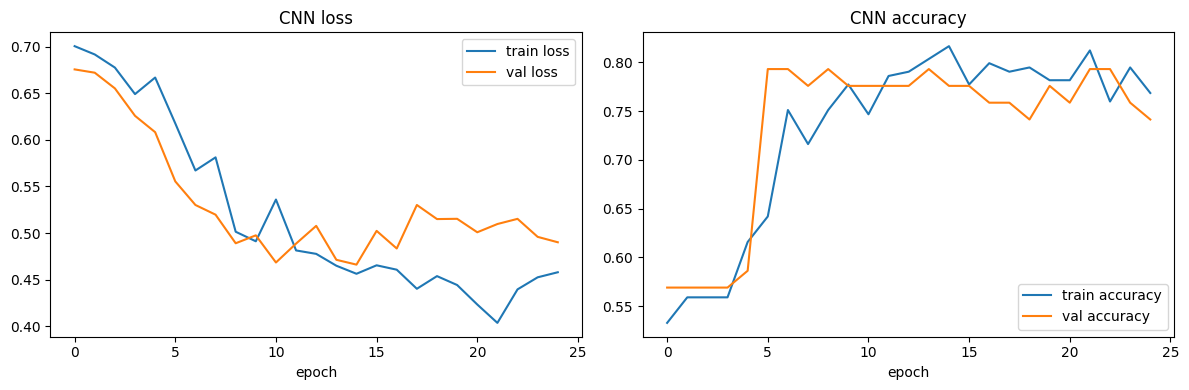

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("CNN loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("CNN accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


### Evaluate the CNN on the test set

Same metrics as the SVM: accuracy, precision, recall, F1, classification
report, and a confusion matrix, so the two models can be compared directly.


In [45]:
y_prob_cnn = cnn_model.predict(X_test_img).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

cnn_accuracy = accuracy_score(y_test_img, y_pred_cnn)
cnn_precision = precision_score(y_test_img, y_pred_cnn, zero_division=0)
cnn_recall = recall_score(y_test_img, y_pred_cnn, zero_division=0)
cnn_f1 = f1_score(y_test_img, y_pred_cnn, zero_division=0)

cnn_summary = pd.DataFrame([{
    "model": "CNN (raw image patches)",
    "accuracy": cnn_accuracy,
    "precision": cnn_precision,
    "recall": cnn_recall,
    "f1": cnn_f1
}])

cnn_summary


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


,model,accuracy,precision,recall,f1
0,CNN (raw image patches),0.772358,0.859649,0.710145,0.777778


In [46]:
print(classification_report(
    y_test_img,
    y_pred_cnn,
    target_names=["not cone", "cone"],
    zero_division=0
))


              precision    recall  f1-score   support

    not cone       0.70      0.85      0.77        54
        cone       0.86      0.71      0.78        69

    accuracy                           0.77       123
   macro avg       0.78      0.78      0.77       123
weighted avg       0.79      0.77      0.77       123



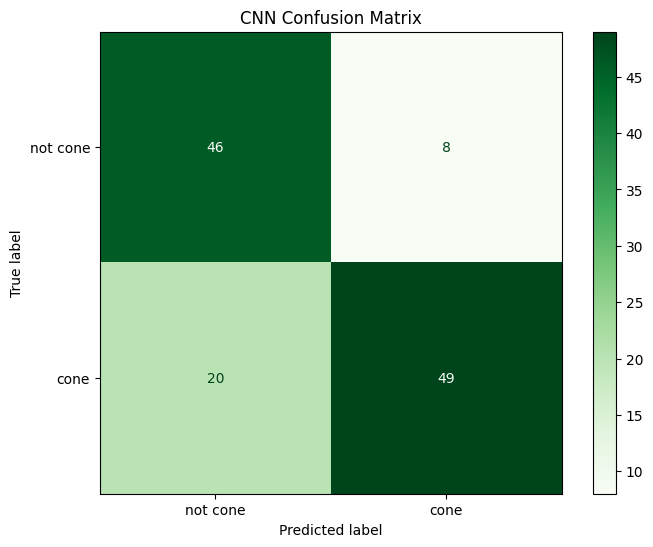

In [47]:
ConfusionMatrixDisplay.from_predictions(
    y_test_img,
    y_pred_cnn,
    display_labels=["not cone", "cone"],
    cmap="Greens"
)

plt.title("CNN Confusion Matrix")
plt.show()


### Cross-validation for the CNN

To get a more stable estimate than a single train/test split, I repeat
training and evaluation across 5 stratified folds, exactly like the SVM's
cross-validation, and report the mean and standard deviation of the F1 score.
Each fold builds and trains a fresh CNN from scratch.


In [49]:
cnn_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cnn_cv_f1_scores = []

for fold, (train_idx, test_idx) in enumerate(cnn_cv.split(X_img, y_img), start=1):
    X_tr, X_te = X_img[train_idx], X_img[test_idx]
    y_tr, y_te = y_img[train_idx], y_img[test_idx]

    X_tr, X_va, y_tr, y_va = cnn_train_test_split(
        X_tr, y_tr, test_size=0.20, random_state=RANDOM_STATE, stratify=y_tr
    )

    fold_model = build_cnn((CNN_PATCH_SIZE, CNN_PATCH_SIZE, 1))
    fold_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    fold_model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=60,
        batch_size=16,
        callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
        verbose=0
    )

    fold_prob = fold_model.predict(X_te, verbose=0).ravel()
    fold_pred = (fold_prob >= 0.5).astype(int)
    fold_f1 = f1_score(y_te, fold_pred, zero_division=0)
    cnn_cv_f1_scores.append(fold_f1)

    print(f"Fold {fold}: F1 = {fold_f1:.3f}")

cnn_cv_f1_scores = np.array(cnn_cv_f1_scores)
print("\nCNN mean F1:", cnn_cv_f1_scores.mean())
print("CNN standard deviation:", cnn_cv_f1_scores.std())


Fold 1: F1 = 0.809
Fold 2: F1 = 0.839
Fold 3: F1 = 0.822
Fold 4: F1 = 0.864
Fold 5: F1 = 0.816

CNN mean F1: 0.829976711587026
CNN standard deviation: 0.019474035823595626


### Compare SVM (hand-crafted features) vs CNN (raw images)

Both models were evaluated on stratified train/test splits of comparable
size, using the same random state, and both were cross-validated with 5
folds.


In [50]:
full_comparison = pd.concat([svm_summary, best_svm_summary, cnn_summary], ignore_index=True)
full_comparison["cv_mean_f1"] = [
    cv_f1_scores.mean(),
    tuned_cv_f1_scores.mean(),
    cnn_cv_f1_scores.mean()
]
full_comparison["cv_std_f1"] = [
    cv_f1_scores.std(),
    tuned_cv_f1_scores.std(),
    cnn_cv_f1_scores.std()
]

full_comparison


,model,accuracy,precision,recall,f1,cv_mean_f1,cv_std_f1
0,SVM with RBF kernel,0.699187,0.735294,0.724638,0.729927,0.839737,0.021097
1,Tuned SVM,0.723577,0.733333,0.797101,0.763889,0.848152,0.021443
2,CNN (raw image patches),0.772358,0.859649,0.710145,0.777778,0.829977,0.019474


### Notes on the comparison

- The **SVM** relies on features I chose myself (brightness, roughness, blob
  count, etc.). This works reasonably well and is easy to interpret, but it
  can only be as good as the features I thought to design.
- The **CNN** learns its own filters directly from raw pixels, so it can pick
  up on patterns I didn't explicitly encode. In exchange it needs more data to
  train reliably and is more prone to overfitting on a small dataset like this
  one — which is why data augmentation and early stopping are used above.
- With more labeled cone examples (e.g. from more volcanic fields, not just
  Etna), the CNN would be expected to pull further ahead of the hand-crafted
  feature approach, since deep learning models tend to scale better with data.
